<a href="https://colab.research.google.com/github/ASBRUC/Consumer-Loan-Default-Project/blob/main/consumerloandefault.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Consumer Loan Default Project
By Alex Bruce

In [ ]:
#imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve, precision_score, recall_score
from sklearn.linear_model import LogisticRegression

**Goal: Loan-Appproval Triage** <br>
Auto-approve = lowest-risk bucket <br>
Manual review = middle / borderline <br>
Auto-decline = highest-risk bucket

**Exploratory Analysis** done partly in SQLite <br>
Checking status shows strong separation in risk: categories A11 ~49% bad, n=274 and A12, ~39% bad, n=269 are substantially above the overall baseline.

**Two-way segmentation:** <br>
We used a two-way segmentation to check whether each variable’s risk target holds after conditioning on the other, and to see whether the combination produces higher/lower risk than either variable alone (interaction) <br>
**Found Interaction** <br>
Longer durations amplify risk more strongly for high-risk checking categories (A11/A12) than for low-risk categories (A14).

**Correlation from target categories:** <br>
Credit_status, duration_bucket, count, bad_rate_pct<br>
A11	37+	26	76.92 <br>
A12	37+	36	58.33 <br>
A11	25–36	38	57.89 <br>
A12	25–36	44	52.27 <br>
A11	13–24	118	50.85 <br>
A11	0–12	92	35.87 <br>
A12	13–24	98	34.69 <br>
A12	0–12	91	29.67 <br>
A14	25–36	54	18.52 <br>
A13	0–12	30	16.67 <br>
A14	13–24	171	12.28 <br>
A14	0–12	146	7.53 <br>


In [ ]:
#The data above (values are missing bc n < 25)
A11 = [35.87, 50.85, 57.89, 76.92]
A12 = [29.67, 34.69, 52.27, 58.33]
A13 = [16.67]
A14 = [7.53, 12.28, 18.52]

# EDA Python part -
Logistic Regression <br>
Random Forrest

**Important Information:** <br>
bad_rate = 1 for n = 300 (1000 total) => 0.30 <br>
bad_rate = 0 for n = 700 => 0.70

In [ ]:
#Mounting google drive
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/MyDrive/CreditRiskProject

Mounted at /content/drive/
/content/drive/MyDrive/CreditRiskProject


In [ ]:
%ls

ConsumerLoanDefault.ipynb     german.data          german.doc
german_credit_model_data.csv  german.data-numeric  Index


In [ ]:
#SQLite cleaned data:
gc_data = pd.read_csv("german_credit_model_data.csv")

In [ ]:
gc_data.head()
gc_data.columns

Index(['checking_status', 'duration_months', 'credit_history', 'purpose',
       'credit_amount', 'savings_status', 'employment_length',
       'installment_rate', 'other_debtors', 'residence_since', 'property',
       'age', 'other_installment_plans', 'housing', 'existing_credits', 'job',
       'num_liable_people', 'telephone', 'bad_credit'],
      dtype='object')

In [ ]:
#Raw bad rate percent
gc_data['bad_credit'].value_counts(normalize=True)

,proportion
bad_credit,
0,0.7
1,0.3


In [ ]:
gc_data['bad_credit'].mean()

np.float64(0.3)

**Need One-Hot Encoding for categorial variables** <br>
Using a transformer pipeline *from sklearn library*

In [ ]:
df = pd.read_csv("german_credit_model_data.csv")

#separating bad credit as my target
X = df.drop(columns=["bad_credit"])
y = df["bad_credit"]

categorical_cols = [
    "checking_status", "credit_history", "purpose", "savings_status",
    "employment_length", "other_debtors", "property", "other_installment_plans",
    "housing", "job", "telephone"
]
numeric_cols = [
    "duration_months", "credit_amount", "installment_rate", "residence_since",
    "age", "existing_credits", "num_liable_people"
]

#Create the Transformer
preprocess_onehot = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

#Perform the Transformer
X_encoded = preprocess_onehot.fit_transform(X)

#renaming
cat_feature_names = preprocess_onehot.named_transformers_["cat"].get_feature_names_out(categorical_cols)
feature_names = list(cat_feature_names) + numeric_cols

In [ ]:
#cat_feature_names
#feature_names

In [ ]:
#Train/test split (stratified keeps the 70/30 class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=303, stratify=y
)

#Logistic Regression model, balanced handles 70/30 imbalance
#Using a linear loss function that should be fine for 1000 rows
log_reg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess_onehot),
        ("model", LogisticRegression(max_iter=10000, solver="liblinear", class_weight="balanced"))
    ]
)

#Perform the pipeline
log_reg_pipeline.fit(X_train, y_train)

#Predict class + probability
y_pred = log_reg_pipeline.predict(X_test)
y_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

#Evaluate
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))
print("\nROC-AUC:", roc_auc_score(y_test, y_proba))

Confusion matrix:
 [[161  49]
 [ 28  62]]

Classification report:
               precision    recall  f1-score   support

           0      0.852     0.767     0.807       210
           1      0.559     0.689     0.617        90

    accuracy                          0.743       300
   macro avg      0.705     0.728     0.712       300
weighted avg      0.764     0.743     0.750       300


ROC-AUC: 0.7825925925925925


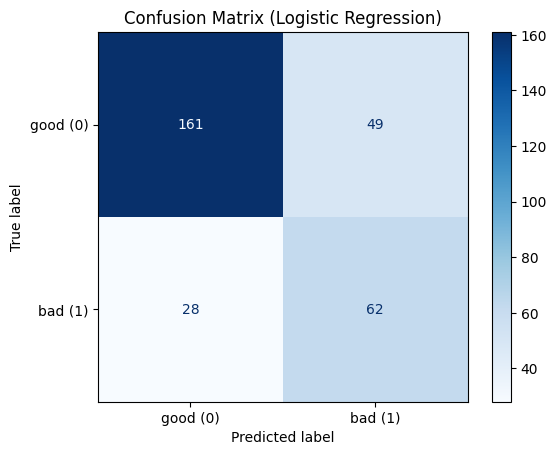

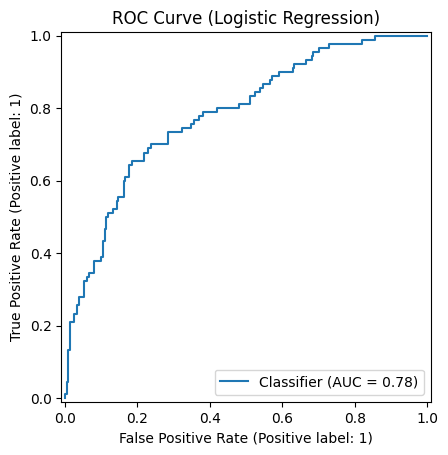

In [ ]:
#Confusion matrix plot
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["good (0)", "bad (1)"],
    ax=ax,
    cmap = "Blues"
)
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()

#ROC curve plot
fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax)
plt.title("ROC Curve (Logistic Regression)")
plt.show()

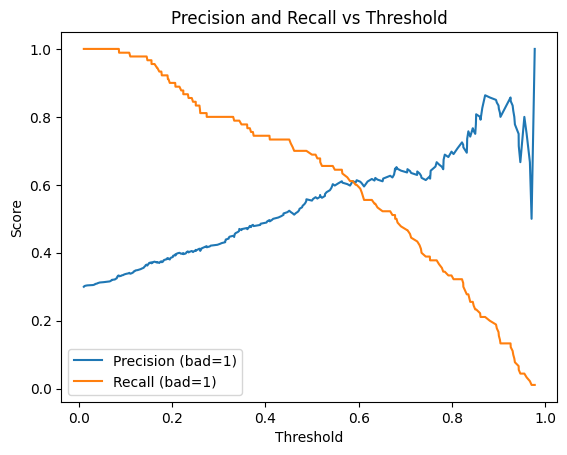

In [ ]:
#Precision and Recall vs Threshold plot
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

#precision_recall_curve returns precision/recall arrays of length len(thresholds)+1
#plotting precision[:-1] $ recall[:-1] against thresholds
fig, ax = plt.subplots()
ax.plot(thresholds, precision[:-1], label="Precision (bad=1)")
ax.plot(thresholds, recall[:-1], label="Recall (bad=1)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision and Recall vs Threshold")
ax.legend()
plt.show()

In [ ]:
#Showing exact scores at certain thresholds
for t in [0.15, 0.2, 0.25, 0.3, 0.5, 0.6, 0.7, 0.8, 0.85]:
    y_hat = (y_proba >= t).astype(int)
    p = precision_score(y_test, y_hat)
    r = recall_score(y_test, y_hat)
    flagged = y_hat.sum()
    print(f"t={t:0.2f}  precision={p:0.3f}  recall={r:0.3f}  predicted_bad={flagged}")

t=0.15  precision=0.369  recall=0.967  predicted_bad=236
t=0.20  precision=0.388  recall=0.900  predicted_bad=209
t=0.25  precision=0.409  recall=0.844  predicted_bad=186
t=0.30  precision=0.426  recall=0.800  predicted_bad=169
t=0.50  precision=0.559  recall=0.689  predicted_bad=111
t=0.60  precision=0.609  recall=0.589  predicted_bad=87
t=0.70  precision=0.636  recall=0.467  predicted_bad=66
t=0.80  precision=0.690  recall=0.322  predicted_bad=42
t=0.85  precision=0.778  recall=0.233  predicted_bad=27


# False Positive vs False Negative...

In [ ]:
#Finding the lower limit
#Want to find the amount of bad withing the auto-approve bucket
#Aiming for %5 or less
def autoapprove_stats(y_true, y_proba, L):
    """Returns (n_in_bucket, bad_rate_in_bucket) for p <= L."""
    bad_rate = 0
    mask = y_proba <= L
    n = int(mask.sum())
    if n > 0:
      bad_rate = float(y_true[mask].mean())
    return n, bad_rate

# Try a few L values
for L in [0.05, 0.10, 0.15, 0.20, 0.25]:
    n, bad_rate = autoapprove_stats(y_test.to_numpy(), y_proba, L)
    print(f"L={L:.2f}  n_autoapprove={n:3d}  bad_rate={bad_rate:.3f}")


L=0.05  n_autoapprove= 13  bad_rate=0.000
L=0.10  n_autoapprove= 37  bad_rate=0.027
L=0.15  n_autoapprove= 64  bad_rate=0.047
L=0.20  n_autoapprove= 91  bad_rate=0.099
L=0.25  n_autoapprove=114  bad_rate=0.123


# Choosing L and U limits
I chose to make these limits highly precise, assuming that there are resources for larger manual review <br>
**Upper limit threshold:** U_t = 0.85, <br> At this threshold, it is 85% precise, a reasonable extreme <br>
**Lower limit threshold:** L_t = 0.15, <br> At this threshold only 4.7% of the auto-approve bucket are bad.


In [ ]:
#Checking the triage policy
import numpy as np

L = 0.15
U = 0.85

p = y_proba
y = y_test.to_numpy()

auto_approve = p <= L
manual_review = (p > L) & (p < U)
auto_decline = p >= U

def summarize_bucket(name, mask):
    n = mask.sum()
    bad_rate = y[mask].mean() if n > 0 else np.nan
    return name, int(n), float(bad_rate)

for name, mask in [
    ("auto_approve", auto_approve),
    ("manual_review", manual_review),
    ("auto_decline", auto_decline),
]:
    print(summarize_bucket(name, mask))

('auto_approve', 64, 0.046875)
('manual_review', 209, 0.3157894736842105)
('auto_decline', 27, 0.7777777777777778)
